<a href="https://colab.research.google.com/github/ab1991sharma/quantum_study/blob/main/Session_6_18_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit qiskit-aer matplotlib pylatexenc ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 68.9 MB/s eta 0:00:00


# Demo: Deutsch Algorithm

## Objective

In this experiment, we will explore the **Deutsch Algorithm**, the first quantum algorithm to demonstrate that a quantum computer can solve certain problems more efficiently than a classical computer.

The goal is not to determine the exact function inside a black box, but to identify **whether the function is Constant or Balanced using only one function evaluation (one oracle call).**

By the end of this experiment, you will understand how **superposition, interference, and quantum oracles** work together to provide a computational advantage.

---

# The Problem

Imagine you are given a mysterious black box (called an **Oracle**) that implements a function **f(x)**.

The function can be one of two types:

### Constant Function

The output is always the same regardless of the input.

| Input | Output |
|-------|--------|
| 0 | 0 |
| 1 | 0 |

or

| Input | Output |
|-------|--------|
| 0 | 1 |
| 1 | 1 |

---

### Balanced Function

The output changes depending on the input.

| Input | Output |
|-------|--------|
| 0 | 0 |
| 1 | 1 |

or

| Input | Output |
|-------|--------|
| 0 | 1 |
| 1 | 0 |

Our task is simple:

> **Determine whether the hidden function is Constant or Balanced.**

---

# Classical Approach

A classical computer must evaluate the function twice.

1. Evaluate **f(0)**
2. Evaluate **f(1)**
3. Compare the outputs

Only after checking both inputs can it determine whether the function is Constant or Balanced.

---

# Quantum Approach

A quantum computer prepares a superposition of both possible inputs.

Instead of checking each input separately, the Oracle processes both possibilities simultaneously.

The Oracle does not directly reveal the answer.

Instead, it encodes information into the **phase** of the quantum state.

A final Hadamard gate converts this hidden phase into **constructive or destructive interference**, allowing a single measurement to determine the answer.

---

# Understanding the Circuit

The circuit consists of five important stages.

### Step 1 – Prepare the Ancilla Qubit

The second qubit is initialized to |1⟩ using an X gate.

This auxiliary qubit (called the **ancilla qubit**) allows the Oracle to encode information into the phase of the first qubit.

---

### Step 2 – Create Superposition

Hadamard gates are applied to both qubits.

The input qubit now represents both possible inputs simultaneously.

Instead of evaluating one input at a time, the quantum computer is prepared to process multiple possibilities at once.

---

### Step 3 – Oracle

The Oracle represents the unknown function.

In this demonstration, the Oracle is implemented using a **Controlled-NOT (CX) gate**, which represents a **Balanced Function**.

The Oracle modifies the quantum state by introducing a phase difference without directly revealing the function.

---

### Step 4 – Quantum Interference

A final Hadamard gate is applied to the input qubit.

This gate converts the hidden phase differences created by the Oracle into measurable interference.

Constructive interference amplifies one result while destructive interference suppresses the other.

---

### Step 5 – Measurement

Only the first qubit is measured.

The measurement immediately tells us whether the hidden function is Constant or Balanced.

---

# Why Does This Work?

The power of the Deutsch Algorithm comes from three fundamental quantum principles.

### Superposition

The Hadamard gate allows the input qubit to represent both possible inputs at the same time.

---

### Phase Encoding

The Oracle stores information by changing the phase of the quantum state instead of changing its measurement probabilities directly.

---

### Quantum Interference

The final Hadamard gate combines the probability amplitudes.

Depending on the phase introduced by the Oracle, the amplitudes either reinforce or cancel each other.

This interference allows the answer to appear after only one Oracle evaluation.

---

# Expected Results

For a **Constant Function**

```
Measurement = 0
```

For a **Balanced Function**

```
Measurement = 1
```

Since the Oracle in this demonstration is implemented using a **CX gate**, the measurement is expected to indicate a **Balanced Function**.

---

# Applications

Although the Deutsch Algorithm solves a simple problem, it introduced ideas that became the foundation of modern quantum algorithms.

Its principles are used in:

- Deutsch–Jozsa Algorithm
- Bernstein–Vazirani Algorithm
- Simon's Algorithm
- Grover's Search Algorithm
- Shor's Factoring Algorithm

Nearly every quantum algorithm relies on the same concepts of superposition, phase encoding, and interference.

---

# What to Observe

While running the experiment, pay attention to the following:

1. Why is the second qubit initialized to |1⟩?
2. What role do the Hadamard gates play?
3. How does the Oracle modify the quantum state?
4. Why is only the first qubit measured?
5. What measurement result is obtained?
6. How does that result indicate whether the function is Constant or Balanced?

---

> **Key Takeaway:** The Deutsch Algorithm demonstrates that a quantum computer can determine whether a hidden function is Constant or Balanced using a single Oracle evaluation by exploiting superposition, phase encoding, and quantum interference.

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Choose the oracle
# ------------------------------------------------------------
oracle_type = "balanced"     # Change to "constant"

# ------------------------------------------------------------
# Create the quantum circuit
# ------------------------------------------------------------
qc = QuantumCircuit(2, 1)

# ------------------------------------------------------------
# 1. Prepare the auxiliary qubit in |1⟩
# ------------------------------------------------------------
qc.x(1)

# ------------------------------------------------------------
# 2. Create superposition
# ------------------------------------------------------------
qc.h(0)
qc.h(1)

# ------------------------------------------------------------
# 3. Oracle
# ------------------------------------------------------------
if oracle_type == "constant":

    # Constant function: f(x) = 0
    # Do nothing

    oracle_name = "Constant Oracle: f(x) = 0"

elif oracle_type == "balanced":

    # Balanced function: f(x) = x
    qc.cx(0, 1)

    oracle_name = "Balanced Oracle: f(x) = x"

# ------------------------------------------------------------
# 4. Interference
# ------------------------------------------------------------
qc.h(0)

# ------------------------------------------------------------
# 5. Measure the input qubit
# ------------------------------------------------------------
qc.measure(0, 0)

# ============================================================
# DISPLAY CIRCUIT
# ============================================================

print("\n" + "=" * 60)
print("             DEUTSCH ALGORITHM")
print("=" * 60)

print(f"\nSelected Oracle: {oracle_name}\n")

print(qc.draw("text"))

# ============================================================
# RUN SIMULATION
# ============================================================

simulator = AerSimulator()

compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=1024
).result()

counts = result.get_counts()

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\nMeasurement Results:")
print(counts)

# Determine result
if counts.get("0", 0) > counts.get("1", 0):
    result_text = "CONSTANT"
    explanation = "The function gives the same output for both inputs."

else:
    result_text = "BALANCED"
    explanation = "The function gives different outputs for the two inputs."

print("\n" + "=" * 60)
print(f"        RESULT: {result_text}")
print("=" * 60)
print(explanation)

# ============================================================
# HISTOGRAM
# ============================================================

plot_histogram(
    counts,
    title=f"Deutsch Algorithm — {result_text} Function"
)

plt.show()


             DEUTSCH ALGORITHM

Selected Oracle: Balanced Oracle: f(x) = x

     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 

Measurement Results:
{'1': 1024}

        RESULT: BALANCED
The function gives different outputs for the two inputs.



             DEUTSCH ALGORITHM

Selected Oracle: Balanced Oracle: f(x) = x



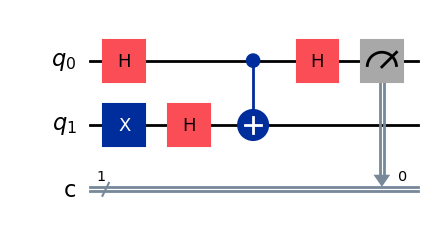


Measurement Results:
{'1': 1024}

        RESULT: BALANCED
The function gives different outputs for the two inputs.


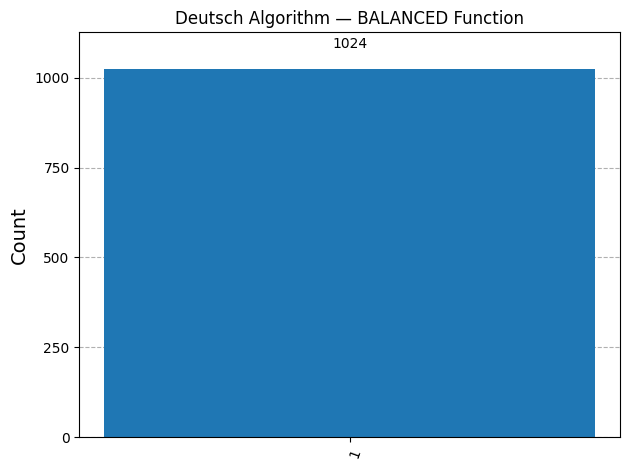

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from IPython.display import display


# Choose the oracle
oracle_type = "balanced"     # Change to "constant"


# Create the quantum circuit
qc = QuantumCircuit(2, 1)


# 1. Prepare the auxiliary qubit in |1⟩
qc.x(1)


# 2. Create superposition

qc.h(0)
qc.h(1)


# 3. Oracle
if oracle_type == "constant":

    # Constant function: f(x) = 0
    # Do nothing

    oracle_name = "Constant Oracle: f(x) = 0"

elif oracle_type == "balanced":

    # Balanced function: f(x) = x
    qc.cx(0, 1)

    oracle_name = "Balanced Oracle: f(x) = x"


# 4. Interference
qc.h(0)

# 5. Measure the input qubit
qc.measure(0, 0)

# DISPLAY CIRCUIT
print("\n" + "=" * 60)
print("             DEUTSCH ALGORITHM")
print("=" * 60)

print(f"\nSelected Oracle: {oracle_name}\n")

# Create circuit figure
circuit_fig = qc.draw(
    output="mpl",
    fold=-1
)

# Explicitly display the circuit
display(circuit_fig)

# Close the figure so it does not interfere with the histogram
plt.close(circuit_fig)


# RUN SIMULATION
simulator = AerSimulator()

compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=1024
).result()

counts = result.get_counts()


# DISPLAY RESULTS

print("\nMeasurement Results:")
print(counts)

# Determine result
if counts.get("0", 0) > counts.get("1", 0):

    result_text = "CONSTANT"
    explanation = "The function gives the same output for both inputs."

else:

    result_text = "BALANCED"
    explanation = "The function gives different outputs for the two inputs."

print("\n" + "=" * 60)
print(f"        RESULT: {result_text}")
print("=" * 60)

print(explanation)


# HISTOGRAM

histogram_fig = plot_histogram(
    counts,
    title=f"Deutsch Algorithm — {result_text} Function"
)

# Explicitly display histogram
display(histogram_fig)

# Close figure after displaying
plt.close(histogram_fig)

# Demo: Deutsch–Jozsa Algorithm

## Objective

In this experiment, we will explore the **Deutsch–Jozsa Algorithm**, one of the earliest quantum algorithms to demonstrate a clear advantage over classical computing.

Unlike the Deutsch Algorithm, which works with a single input bit, the Deutsch–Jozsa Algorithm determines whether an unknown function is **Constant or Balanced** for **multiple input bits**.

By the end of this experiment, you will understand how **superposition, phase encoding, interference, and quantum parallelism** enable a quantum computer to solve this problem with just **one Oracle evaluation**.

---

# The Problem

Suppose we are given a hidden function:

```
f(x)
```

where **x** is a binary string of length **n**.

The function is guaranteed to be either:

### Constant Function

Every possible input produces the same output.

Example:

| Input | Output |
|-------|--------|
|000|0|
|001|0|
|010|0|
|...|...|
|111|0|

or

| Input | Output |
|-------|--------|
|000|1|
|001|1|
|010|1|
|...|...|
|111|1|

---

### Balanced Function

Exactly half of all possible inputs produce **0**, while the other half produce **1**.

Example (3 input qubits):

| Input | Output |
|-------|--------|
|000|0|
|001|1|
|010|0|
|011|1|
|100|0|
|101|1|
|110|0|
|111|1|

Our objective is **not** to determine every output.

Instead, we only want to answer one question:

> **Is the hidden function Constant or Balanced?**

---

# Classical Approach

For a function with **n input bits**, there are:

```
2ⁿ
```

possible inputs.

A classical computer may need to evaluate the function many times before it can confidently determine whether it is Constant or Balanced.

In the worst case, it may require:

```
2ⁿ⁻¹ + 1
```

function evaluations.

As the number of input bits increases, the number of required evaluations grows exponentially.

---

# Quantum Approach

A quantum computer prepares **all possible input states simultaneously** using superposition.

Instead of evaluating each input separately, the Oracle processes every possible input in a single operation.

The Oracle stores information as **phase changes**, and the final Hadamard gates convert those phase differences into measurable interference.

A single measurement is then enough to determine whether the function is Constant or Balanced.

---

# Understanding the Circuit

This experiment uses **three input qubits** and **one output (ancilla) qubit**.

The circuit consists of five main stages.

### Step 1 – Prepare the Output Qubit

The output qubit is initialized to **|1⟩** using an X gate.

This ancilla qubit allows the Oracle to encode information into the phase of the input qubits.

---

### Step 2 – Create Superposition

Hadamard gates are applied to all qubits.

The three input qubits now represent all:

```
2³ = 8
```

possible input combinations simultaneously.

This is an example of **quantum parallelism**.

---

### Step 3 – Oracle

The Oracle represents the hidden function.

In this demonstration, the Oracle is implemented using **Controlled-NOT (CX) gates** between each input qubit and the output qubit.

This Oracle represents a **Balanced Function**, because different input combinations produce different outputs while maintaining an equal number of zeros and ones.

Rather than revealing the outputs directly, the Oracle changes the **phase** of specific quantum states.

---

### Step 4 – Quantum Interference

Hadamard gates are applied again to the input qubits.

These gates combine the probability amplitudes.

Depending on the phase introduced by the Oracle, the amplitudes either reinforce or cancel each other.

This interference allows the quantum computer to distinguish between Constant and Balanced functions.

---

### Step 5 – Measurement

Only the three input qubits are measured.

The measurement outcome reveals the type of hidden function.

---

# Expected Results

### Constant Function

If the hidden function is Constant, the measurement result is:

```
000
```

with very high probability.

---

### Balanced Function

If the hidden function is Balanced, at least one measured qubit will be **1**.

The measurement result will therefore be **anything except 000**.

Since this demonstration uses a **Balanced Oracle**, the simulator is expected to produce a non-zero bit string, confirming that the hidden function is Balanced.

---

# Why Does This Work?

The Deutsch–Jozsa Algorithm combines several important quantum principles.

### Superposition

The Hadamard gates prepare every possible input simultaneously.

---

### Quantum Parallelism

The Oracle evaluates all possible inputs in a single quantum operation instead of processing them one at a time.

---

### Phase Encoding

The Oracle stores information by changing the phase of the quantum states rather than their probabilities.

---

### Quantum Interference

The final Hadamard gates transform these hidden phase differences into measurable outcomes.

Constructive and destructive interference reveal whether the hidden function is Constant or Balanced.

---

# Why is This Important?

The Deutsch–Jozsa Algorithm was one of the first examples showing that a quantum computer can solve a specific problem exponentially faster in terms of **query complexity** than a deterministic classical algorithm.

Although the problem itself is specialized, the ideas introduced by this algorithm laid the foundation for many modern quantum algorithms.

---

# Applications

The concepts demonstrated by the Deutsch–Jozsa Algorithm are used in:

- Quantum Algorithm Design
- Oracle-Based Quantum Computing
- Quantum Complexity Theory
- Bernstein–Vazirani Algorithm
- Simon's Algorithm
- Grover's Search Algorithm
- Shor's Factoring Algorithm
- Quantum Information Processing

---

# What to Observe

While running the experiment, pay attention to the following:

1. Why is an additional output (ancilla) qubit required?
2. How do the Hadamard gates create quantum parallelism?
3. What role do the CX gates play in the Oracle?
4. Why are the input qubits measured instead of the output qubit?
5. What measurement outcome indicates a Constant function?
6. Why does any non-zero bit string indicate a Balanced function?

---

> **Key Takeaway:** The Deutsch–Jozsa Algorithm demonstrates how a quantum computer can determine whether a hidden function is Constant or Balanced using a single Oracle evaluation by combining superposition, quantum parallelism, phase encoding, and interference.


             DEUTSCH-JOZSA ALGORITHM


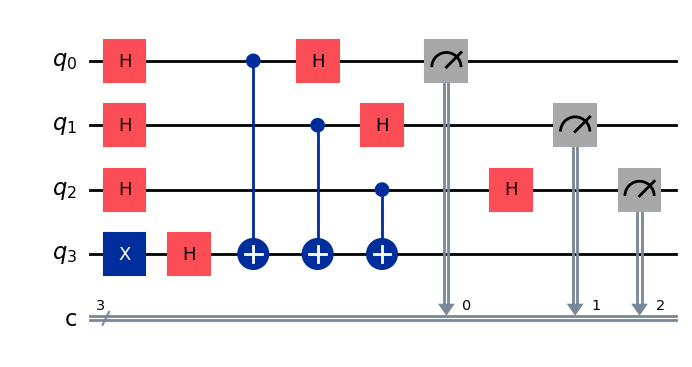


Measurement Results:
{'111': 1000}


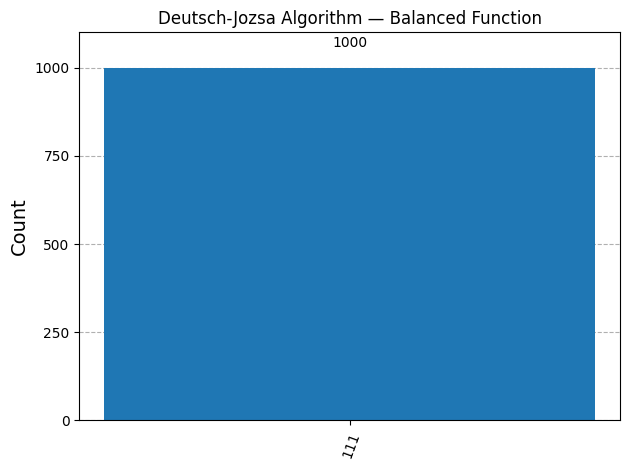

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display
import matplotlib.pyplot as plt

# Number of input qubits
n = 3

# Create quantum circuit
# n input qubits + 1 auxiliary qubit
# n classical bits for measuring the input qubits
qc = QuantumCircuit(n + 1, n)


# 1. Prepare the auxiliary qubit in |1⟩
qc.x(n)


# 2. Create superposition
qc.h(range(n + 1))


# 3. Balanced oracle
# f(x0, x1, x2) = x0 ⊕ x1 ⊕ x2
for i in range(n):
    qc.cx(i, n)


# 4. Interference
qc.h(range(n))


# 5. Measure the input qubits
qc.measure(range(n), range(n))


# ============================
# DISPLAY CIRCUIT
# ============================

print("\n" + "=" * 60)
print("             DEUTSCH-JOZSA ALGORITHM")
print("=" * 60)

circuit_fig = qc.draw(
    output="mpl",
    fold=-1
)

display(circuit_fig)

plt.close(circuit_fig)


# ============================
# RUN SIMULATION
# ============================

sim = AerSimulator()

compiled = transpile(qc, sim)

result = sim.run(
    compiled,
    shots=1000
).result()

counts = result.get_counts()


# ============================
# DISPLAY RESULTS
# ============================

print("\nMeasurement Results:")
print(counts)


# ============================
# HISTOGRAM
# ============================

histogram_fig = plot_histogram(
    counts,
    title="Deutsch-Jozsa Algorithm — Balanced Function"
)

display(histogram_fig)

plt.close(histogram_fig)

# Demo: Grover's Search Algorithm

## Objective

In this experiment, we will explore **Grover's Search Algorithm**, one of the most important quantum algorithms.

Grover's Algorithm is designed to search for a desired item in an **unsorted database** much faster than a classical computer.

In this demonstration, we will search for the quantum state **|11⟩**, which has been marked by the Oracle.

By the end of this experiment, you will understand how **superposition, phase marking, and amplitude amplification** work together to make the correct answer more likely to be measured.

---

# The Problem

Imagine you have four locked boxes.

Only one box contains the treasure.

```
□  □  □  □
```

A classical computer has no information about which box is correct.

The only option is to check each box one by one.

For four possibilities, a classical computer may need up to **4 searches** in the worst case.

As the number of possibilities increases, the search becomes increasingly time-consuming.

---

# Quantum Approach

A quantum computer searches differently.

Instead of checking one possibility at a time, it:

1. Creates a superposition of all possible states.
2. Marks the correct answer by changing its phase.
3. Amplifies the probability of the correct answer using interference.
4. Measures the qubits.

As a result, the marked state becomes much more likely to be observed.

---

# Understanding the Circuit

This experiment uses **2 qubits**, giving:

```
2² = 4
```

possible states:

```
|00⟩
|01⟩
|10⟩
|11⟩
```

The circuit consists of four major stages.

---

### Step 1 – Create Superposition

Hadamard gates are applied to both qubits.

This prepares an equal superposition of all four possible states.

Initially, every state has the same probability of being measured.

---

### Step 2 – Oracle

The Oracle identifies the target state.

In this experiment, a **Controlled-Z (CZ) gate** is used to mark the state:

```
|11⟩
```

The Oracle does **not** change the measurement probabilities.

Instead, it changes only the **phase** of the marked state.

This hidden phase acts like a label, identifying the correct answer without revealing it directly.

---

### Step 3 – Diffusion Operator

After the Oracle, the circuit applies the **Diffusion Operator**, also known as the **Amplitude Amplification Operator**.

It consists of:

- Hadamard gates
- X gates
- Controlled-Z gate
- X gates
- Hadamard gates

The diffusion operator increases the probability amplitude of the marked state while decreasing the amplitudes of the unmarked states.

This process is called **Amplitude Amplification**.

It is the key idea behind Grover's Algorithm.

---

### Step 4 – Measurement

Finally, both qubits are measured.

Because the marked state's amplitude has been amplified, it is much more likely to appear in the measurement results.

---

# Expected Results

Since the Oracle marks the state:

```
|11⟩
```

the histogram should show:

```
11
```

with the highest probability.

The other three states:

```
00
01
10
```

should appear very rarely or not at all in an ideal simulation.

---

# Why Does This Work?

Grover's Algorithm relies on three fundamental quantum principles.

### Superposition

The Hadamard gates prepare all possible states simultaneously.

Instead of searching one possibility at a time, the quantum computer considers every possibility at once.

---

### Phase Marking

The Oracle identifies the correct answer by changing only its phase.

The probabilities remain unchanged after this step.

---

### Amplitude Amplification

The diffusion operator uses quantum interference to amplify the marked state's probability amplitude while suppressing the amplitudes of the other states.

As a result, the correct answer becomes much more likely to be measured.

---

# Quantum Advantage

Suppose there are **N** possible items.

A classical search requires approximately:

```
N
```

checks.

Grover's Algorithm requires approximately:

```
√N
```

Oracle evaluations.

For very large databases, this provides a significant speedup over classical search methods.

---

# Applications

Grover's Algorithm has applications in many areas of quantum computing, including:

- Database Search
- Optimization Problems
- Artificial Intelligence
- Constraint Satisfaction Problems
- Pattern Matching
- Cryptanalysis
- Quantum Machine Learning
- Route and Scheduling Optimization

---

# What to Observe

While running the experiment, pay attention to the following:

1. Why are Hadamard gates applied at the beginning of the circuit?
2. What is the purpose of the Oracle?
3. Why does the Controlled-Z gate only change the phase of the marked state?
4. What operations make up the diffusion operator?
5. How does the diffusion operator amplify the probability of the marked state?
6. Which state dominates the histogram, and why?

---

> **Key Takeaway:** Grover's Search Algorithm finds a desired item by combining superposition, phase marking, and amplitude amplification. Rather than checking every possibility individually, it uses quantum interference to make the correct answer significantly more likely to appear during measurement, providing a quadratic speedup over classical search algorithms.


             GROVER'S SEARCH ALGORITHM


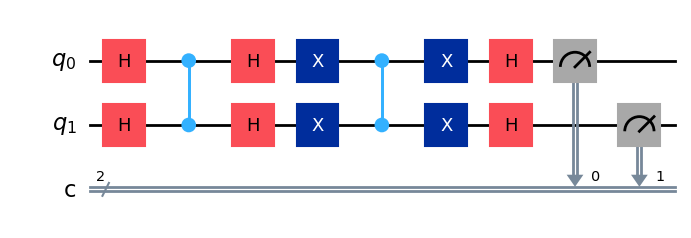


Measurement Results:
{'11': 1024}


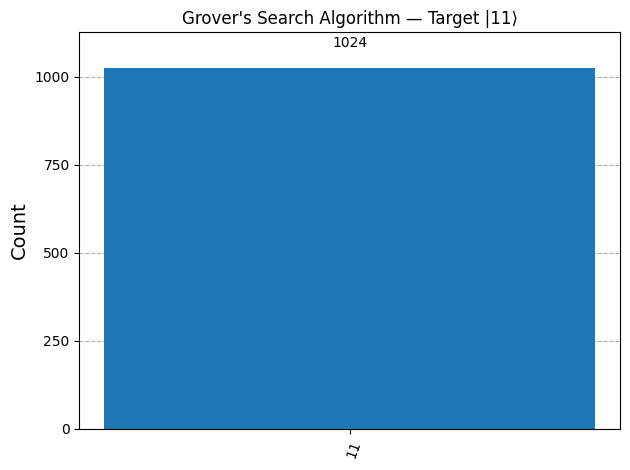

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display
import matplotlib.pyplot as plt


# Create a 2-qubit circuit with 2 classical bits
qc = QuantumCircuit(2, 2)


# 1. Create superposition
qc.h([0, 1])


# 2. Oracle: mark |11⟩
qc.cz(0, 1)


# 3. Diffusion operator
qc.h([0, 1])
qc.x([0, 1])
qc.cz(0, 1)
qc.x([0, 1])
qc.h([0, 1])


# 4. Measure both qubits
qc.measure([0, 1], [0, 1])


# ============================
# DISPLAY CIRCUIT
# ============================

print("\n" + "=" * 60)
print("             GROVER'S SEARCH ALGORITHM")
print("=" * 60)

circuit_fig = qc.draw(
    output="mpl",
    fold=-1
)

display(circuit_fig)

plt.close(circuit_fig)


# ============================
# RUN SIMULATION
# ============================

sim = AerSimulator()

compiled = transpile(qc, sim)

result = sim.run(
    compiled,
    shots=1024
).result()

counts = result.get_counts()


# ============================
# DISPLAY RESULTS
# ============================

print("\nMeasurement Results:")
print(counts)


# ============================
# HISTOGRAM
# ============================

histogram_fig = plot_histogram(
    counts,
    title="Grover's Search Algorithm — Target |11⟩"
)

display(histogram_fig)

plt.close(histogram_fig)

# Demo: Bernstein–Vazirani Algorithm

## Objective

In this experiment, we will explore the **Bernstein–Vazirani Algorithm**, one of the earliest quantum algorithms that demonstrates how a quantum computer can learn hidden information more efficiently than a classical computer.

The goal of the algorithm is to determine a **hidden binary string** stored inside an oracle. While a classical computer must query the oracle multiple times to recover the entire string, a quantum computer can determine the complete hidden string using **only one oracle query**.

This algorithm introduces an important quantum computing concept known as **phase kickback**, which is widely used in many advanced quantum algorithms.

---

# The Problem

Imagine someone secretly chooses a binary string.

For example:

```
Hidden String

1011
```

Your task is to discover this secret string.

The only way to obtain information is by asking an **oracle**, a special function that responds to your queries.

---

# Classical Solution

A classical computer can only query the oracle with one input at a time.

To determine every bit of an **n-bit** hidden string, it generally requires:

```
n Oracle Queries
```

For a 4-bit secret:

```
Hidden String

1011
```

The classical computer needs four carefully chosen queries to determine all four bits.

As the size of the string increases, the number of required queries also increases.

---

# Quantum Solution

A quantum computer prepares all possible inputs simultaneously using **superposition**.

Instead of querying one input at a time, the oracle processes all possibilities in a single operation.

After the oracle applies the hidden information to the quantum state, a second layer of Hadamard gates converts that hidden phase information into measurable bits.

As a result, the quantum computer reveals the entire hidden string using:

```
1 Oracle Query
```

---

# Understanding the Circuit

The Bernstein–Vazirani circuit consists of four main steps.

### Step 1 – Create Superposition

The input qubits begin in:

```
|000...0⟩
```

Hadamard gates are applied to place every input qubit into superposition.

This allows the quantum computer to evaluate multiple inputs simultaneously.

---

### Step 2 – Query the Oracle

The oracle contains the hidden binary string.

It interacts with the qubits by applying controlled operations based on the secret bits.

Although the hidden string is never directly revealed, its information becomes encoded into the **phase** of the quantum state.

This phenomenon is known as **phase kickback**.

---

### Step 3 – Apply Hadamard Gates Again

A second set of Hadamard gates converts the hidden phase information into measurable computational basis states.

Instead of observing complicated phase values, we directly obtain the hidden binary string after measurement.

---

### Step 4 – Measurement

Finally, the input qubits are measured.

The measurement reveals the secret binary string stored inside the oracle.

---

# Phase Kickback

One of the most important ideas introduced by this algorithm is **phase kickback**.

Normally, we think of an operation affecting the target qubit.

However, in certain quantum circuits, information about the target is "kicked back" onto the control qubits as a change in **phase**.

Although quantum phases cannot be measured directly, interference created by the second Hadamard gates converts these phase changes into measurable bit values.

Phase kickback is a fundamental technique used in many advanced quantum algorithms.

---

# Expected Results

Suppose the oracle hides:

```
1011
```

After running the circuit and measuring the input qubits, the histogram will show:

```
1011 → 100%
```

Similarly,

If the hidden string is:

```
0110
```

The measurement result becomes:

```
0110 → 100%
```

The algorithm always returns the correct hidden string (assuming an ideal simulator with no noise).

---

# Why Does This Work?

The power of the Bernstein–Vazirani Algorithm comes from three quantum principles:

- **Superposition** allows all possible inputs to be processed simultaneously.
- **Phase Kickback** encodes the hidden information into the quantum state's phase.
- **Quantum Interference** transforms that hidden phase information into measurable bits.

Together, these principles allow the quantum computer to recover the entire secret string using only one interaction with the oracle.

---

# Applications

Although the Bernstein–Vazirani Algorithm is mainly used for learning and research, it introduces techniques that appear in many important areas of quantum computing, including:

- Oracle-Based Quantum Algorithms
- Quantum Query Complexity
- Quantum Cryptography
- Quantum Machine Learning
- Quantum Phase Estimation
- Shor's Algorithm
- Hidden Structure and Pattern Recognition Problems

---

# Comparison with Previous Algorithms

| Algorithm | Goal | Quantum Advantage |
|------------|------|-------------------|
| Deutsch Algorithm | Determine whether a function is Constant or Balanced (1-bit case) | Uses interference to solve the problem with fewer queries. |
| Deutsch–Jozsa Algorithm | Determine whether a function is Constant or Balanced (n-bit case) | Solves the problem with a single oracle query. |
| **Bernstein–Vazirani Algorithm** | Discover a hidden binary string | Finds the entire hidden string using a single oracle query. |

Notice how each algorithm builds upon the ideas introduced by the previous one while solving a more informative problem.

---

# What to Observe

Run the circuit and observe the measurement results.

While doing so, answer the following questions:

1. What is the hidden binary string encoded inside the oracle?
2. How many oracle queries does the quantum algorithm require?
3. Why does a classical computer need more queries than a quantum computer?
4. What role do the Hadamard gates play before and after the oracle?
5. What is phase kickback, and why is it important?
6. How does interference help recover the hidden string?

---

> **Key Takeaway:** The Bernstein–Vazirani Algorithm demonstrates how a quantum computer can determine an entire hidden binary string with just one oracle query. By combining superposition, phase kickback, and interference, it achieves a task that requires multiple queries on a classical computer, making it one of the foundational quantum algorithms and an important stepping stone toward more advanced algorithms such as Quantum Phase Estimation and Shor's Algorithm.

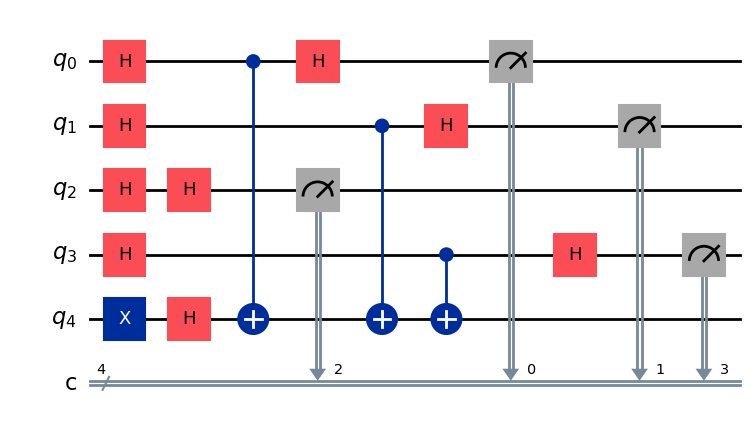

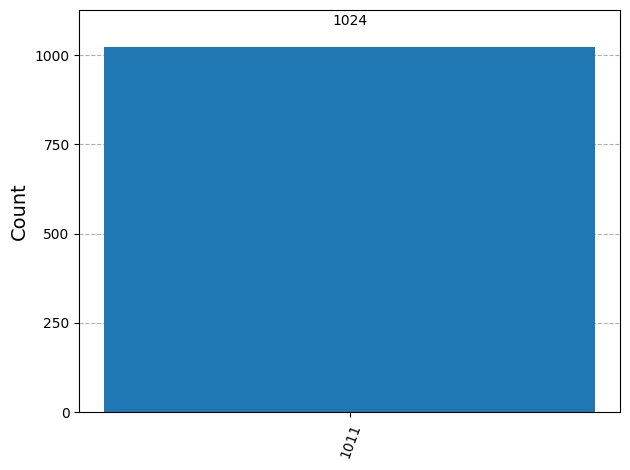

Hidden String : 1011
Measured String: 1011


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

# -----------------------------
# Hidden binary string
# -----------------------------
secret = "1011"      # Change this to any 4-bit string

n = len(secret)

# Create circuit
# n input qubits + 1 ancilla
qc = QuantumCircuit(n + 1, n)

# ---------------------------------
# Step 1: Prepare the ancilla qubit
# ---------------------------------
qc.x(n)
qc.h(n)

# ---------------------------------
# Step 2: Create superposition
# ---------------------------------
for qubit in range(n):
    qc.h(qubit)

# ---------------------------------
# Step 3: Oracle
# ---------------------------------
# If a bit in the secret string is 1,
# apply a CNOT from that input qubit
# to the ancilla.
for i, bit in enumerate(reversed(secret)):
    if bit == "1":
        qc.cx(i, n)

# ---------------------------------
# Step 4: Apply Hadamard again
# ---------------------------------
for qubit in range(n):
    qc.h(qubit)

# ---------------------------------
# Step 5: Measure
# ---------------------------------
qc.measure(range(n), range(n))

# Draw circuit
display(qc.draw("mpl"))

# Run simulation
sim = AerSimulator()
compiled = transpile(qc, sim)

result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

# Display results
display(plot_histogram(counts))

print("Hidden String :", secret)
print("Measured String:", max(counts, key=counts.get))

# Demo: Interactive Grover's Search Algorithm

## Objective

In this interactive experiment, we will explore how **Grover's Search Algorithm** can search for **any desired quantum state**.

Using the interactive menu, we can choose one of the four possible target states:

- |00⟩
- |01⟩
- |10⟩
- |11⟩

The Oracle will mark the selected state, and Grover's Algorithm will amplify its probability, making it the most likely measurement outcome.

By the end of this experiment, you will understand how changing the Oracle changes the search target while the rest of the algorithm remains the same.

---

# The Search Problem

Suppose there are four possible answers.

```
|00⟩
|01⟩
|10⟩
|11⟩
```

Only one of these is the correct answer.

Instead of checking each possibility one at a time, a quantum computer searches all possibilities simultaneously and uses interference to make the correct answer stand out.

---

# Understanding the Circuit

The circuit has four major stages.

### Step 1 – Create Superposition

Hadamard gates are applied to both qubits.

This prepares an equal superposition of all four possible states.

Initially, every state has the same probability of being measured.

---

### Step 2 – Oracle (Mark the Target State)

The Oracle identifies the selected target state.

Using the interactive dropdown, you can choose:

- |00⟩
- |01⟩
- |10⟩
- |11⟩

Depending on your selection, the Oracle applies a combination of **X gates** and a **Controlled-Z (CZ) gate** to change the phase of only the chosen state.

Importantly, the Oracle does **not** increase the probability of the target state—it only marks it by introducing a phase change.

---

### Step 3 – Diffusion Operator

After the Oracle, the circuit applies the **Diffusion Operator**.

It consists of:

- Hadamard gates
- X gates
- Controlled-Z gate
- X gates
- Hadamard gates

The diffusion operator performs **Amplitude Amplification**.

It increases the probability of the marked state while decreasing the probabilities of all other states through quantum interference.

---

### Step 4 – Measurement

Finally, both qubits are measured.

The histogram should show that the selected target state has the highest probability of being measured.

---

# Why Does the Oracle Change?

Every search problem has a different correct answer.

The Oracle is responsible for identifying that answer.

Changing the target from **|00⟩** to **|01⟩**, **|10⟩**, or **|11⟩** simply changes which state's phase is flipped.

The rest of Grover's Algorithm remains exactly the same.

This demonstrates one of the strengths of oracle-based quantum algorithms: **the search procedure stays fixed, while only the Oracle changes to represent a different problem.**

---

# Expected Results

Select each target state one by one.

### Target = |00⟩

The histogram should be dominated by:

```
00
```

---

### Target = |01⟩

The histogram should be dominated by:

```
01
```

---

### Target = |10⟩

The histogram should be dominated by:

```
10
```

---

### Target = |11⟩

The histogram should be dominated by:

```
11
```

Each time the target changes, the measurement outcome changes accordingly, showing that Grover's Algorithm successfully searches for the selected state.

---

# Why Does This Work?

Grover's Algorithm combines three key quantum principles.

### Superposition

The Hadamard gates prepare all possible states simultaneously, allowing the quantum computer to consider every candidate at once.

---

### Phase Marking

The Oracle marks the selected target by changing only its phase.

No probabilities change at this stage.

---

### Amplitude Amplification

The diffusion operator uses constructive and destructive interference to increase the probability of the marked state while reducing the probabilities of the others.

As a result, the target state becomes the most likely measurement outcome.

---

# Applications

Interactive Grover's Search demonstrates the core idea behind many quantum search and optimization problems, including:

- Database Search
- Optimization Problems
- Artificial Intelligence
- Pattern Recognition
- Constraint Satisfaction Problems
- Quantum Cryptanalysis
- Route Planning
- Quantum Machine Learning

---

# What to Observe

Run the demo several times, selecting a different target each time.

While observing the circuit and histogram, answer the following questions:

1. How does changing the target affect the Oracle?
2. Which gates change when a different target is selected?
3. Does the diffusion operator remain the same for every search?
4. Which measurement outcome dominates the histogram for each target?
5. Why does the Oracle only change the phase of the target state?
6. How does amplitude amplification make the selected state the most probable result?

---

> **Key Takeaway:** Grover's Search Algorithm uses the same search procedure for every problem. Only the Oracle changes to mark a different target state, while superposition, phase marking, and amplitude amplification work together to make the selected state the most likely measurement outcome.

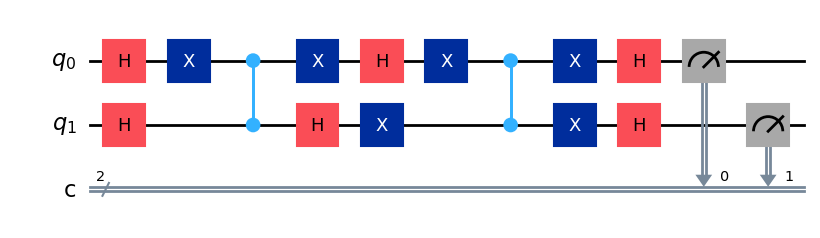

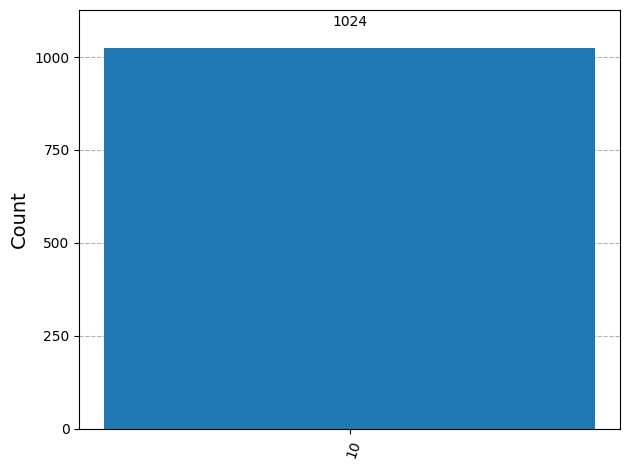

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import ipywidgets as widgets
from IPython.display import display

def grover_demo(target):

    qc = QuantumCircuit(2,2)

    qc.h([0,1])

    # Oracle
    if target == "00":
        qc.x([0,1])
        qc.cz(0,1)
        qc.x([0,1])
    elif target == "01":
        qc.x(0)
        qc.cz(0,1)
        qc.x(0)
    elif target == "10":
        qc.x(1)
        qc.cz(0,1)
        qc.x(1)
    elif target == "11":
        qc.cz(0,1)

    # Diffusion
    qc.h([0,1])
    qc.x([0,1])
    qc.cz(0,1)
    qc.x([0,1])
    qc.h([0,1])

    qc.measure([0,1],[0,1])

    sim = AerSimulator()
    compiled = transpile(qc, sim)
    result = sim.run(compiled, shots=1024).result()

    counts = result.get_counts()

    display(qc.draw("mpl"))
    display(plot_histogram(counts))

widgets.interact(grover_demo, target=["00","01","10","11"])

# Demo: Quantum Fourier Transform (QFT)

## Objective

In this experiment, we will explore the **Quantum Fourier Transform (QFT)**, one of the most important algorithms in quantum computing.

The Quantum Fourier Transform changes the way information is represented inside a quantum computer. Instead of storing information mainly in **probability amplitudes**, it transforms the quantum state so that important information is encoded in its **phase**.

Although the QFT may seem abstract at first, it is a fundamental building block used in many powerful quantum algorithms, including **Shor's Algorithm**, **Quantum Phase Estimation**, and several quantum simulation techniques.

---

# What is the Quantum Fourier Transform?

The Quantum Fourier Transform is the quantum equivalent of the **Classical Discrete Fourier Transform (DFT)**.

In classical computing, the Fourier Transform converts information from the **time domain** into the **frequency domain**.

For example:

```
Sound Wave
     │
     ▼
Frequency Components
```

This idea is used in:

- Audio Compression (MP3)
- Image Processing
- Signal Processing
- Wireless Communication

Similarly, the Quantum Fourier Transform transforms a quantum state into a new representation where **phase information becomes easier to analyze**.

---

# Why Do We Need the QFT?

Many quantum problems hide useful information in the **phase** of a quantum state.

Unfortunately, phases cannot be measured directly.

The Quantum Fourier Transform converts these hidden phase relationships into measurable probability amplitudes.

This allows a quantum computer to detect patterns and solve problems that would otherwise be extremely difficult.

---

# Understanding the Circuit

The Quantum Fourier Transform is built using three main components.

### Step 1 – Hadamard Gates

The algorithm begins by applying a Hadamard gate to a qubit.

This creates superposition and begins encoding phase information into the quantum state.

---

### Step 2 – Controlled Phase Gates

Next, a series of controlled phase rotation gates are applied between qubits.

Each controlled phase gate introduces a precise phase shift depending on the state of another qubit.

These phase relationships are what make the Quantum Fourier Transform so powerful.

Unlike classical algorithms that manipulate numbers directly, QFT manipulates the **relative phases** between quantum states.

---

### Step 3 – Swap Gates

The final step swaps the order of the qubits.

This is necessary because the QFT naturally produces its output in reverse order.

After the swaps, the output qubits appear in the correct order for measurement or further computation.

---

# How Does the QFT Work?

Instead of changing the values stored in the qubits, the Quantum Fourier Transform changes **how those values interfere with one another**.

It reorganizes the quantum state so that hidden patterns become visible.

Conceptually:

```
Original Quantum State
        │
        ▼
Quantum Fourier Transform
        │
        ▼
Phase Information Becomes Observable
```

This transformation makes later measurements much more informative.

---

# Expected Results

Unlike previous algorithms, the Quantum Fourier Transform does **not** solve a problem by itself.

Instead, it transforms a quantum state into another form.

Depending on the input state, you may observe:

- Different probability distributions
- Constructive interference
- Destructive interference
- Changes in the measurement histogram

The output represents the **Fourier-transformed version** of the original quantum state.

---

# Why Does This Work?

The Quantum Fourier Transform relies on three important quantum principles:

- **Superposition** allows multiple computational states to exist simultaneously.
- **Phase Manipulation** changes the relationship between quantum states without changing their probabilities directly.
- **Quantum Interference** combines these phase relationships so that useful information becomes measurable.

Together, these principles enable the QFT to reveal hidden structures inside quantum states.

---

# Applications

The Quantum Fourier Transform is one of the most widely used subroutines in quantum computing.

It is a key component of:

- Shor's Factoring Algorithm
- Quantum Phase Estimation (QPE)
- Order Finding
- Quantum Simulation
- Quantum Chemistry
- Hamiltonian Simulation
- Quantum Machine Learning
- Quantum Signal Processing

Many advanced quantum algorithms would not be possible without the Quantum Fourier Transform.

---

# Comparison with Previous Algorithms

| Algorithm | Main Idea |
|------------|-----------|
| Deutsch Algorithm | Uses interference to distinguish between constant and balanced functions. |
| Deutsch–Jozsa Algorithm | Extends interference to multiple input qubits. |
| Bernstein–Vazirani Algorithm | Uses phase kickback to discover a hidden binary string. |
| Grover's Search Algorithm | Uses amplitude amplification to increase the probability of the correct answer. |
| **Quantum Fourier Transform** | Transforms quantum states by reorganizing their phase information. |

Notice how each algorithm introduces a different quantum principle. The Quantum Fourier Transform focuses on **phase transformation**, making it one of the most fundamental tools in quantum computing.

---

# What to Observe

Run the circuit and observe how the quantum state changes after applying the Quantum Fourier Transform.

While doing so, answer the following questions:

1. What is the purpose of the Hadamard gates in the QFT?
2. Why are controlled phase gates required?
3. Why are the qubits swapped at the end of the circuit?
4. How is the Quantum Fourier Transform different from Grover's Search Algorithm?
5. Why is phase information important in quantum computing?
6. Why is the QFT considered a building block rather than a complete algorithm?

---

> **Key Takeaway:** The Quantum Fourier Transform is one of the most important building blocks in quantum computing. Rather than solving a problem directly, it transforms a quantum state's phase information into a form that can be analyzed through interference and measurement. This ability makes it an essential component of powerful algorithms such as Shor's Algorithm and Quantum Phase Estimation.

/tmp/ipykernel_2924/4046242424.py:23: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(num_qubits=n, do_swaps=True)


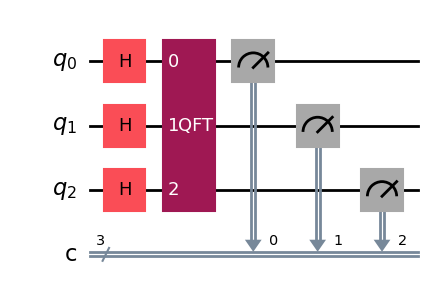

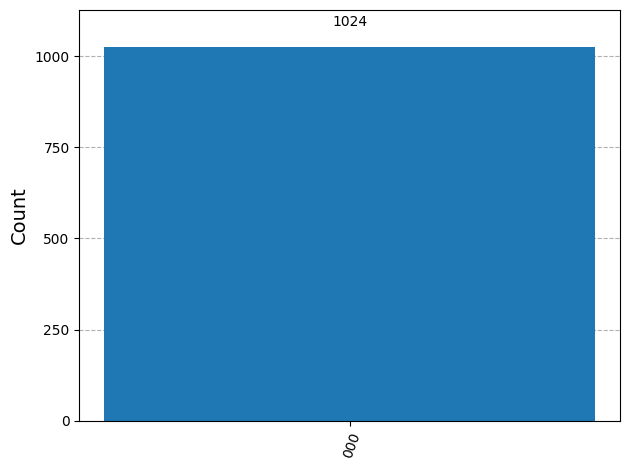

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

# Number of qubits
n = 3

# Create quantum circuit
qc = QuantumCircuit(n, n)

# ---------------------------------
# Prepare an example input state
# ---------------------------------
# Apply Hadamard gates to create superposition
for i in range(n):
    qc.h(i)

# ---------------------------------
# Apply Quantum Fourier Transform
# ---------------------------------
qft = QFT(num_qubits=n, do_swaps=True)
qc.append(qft, range(n))

# ---------------------------------
# Measure
# ---------------------------------
qc.measure(range(n), range(n))

# Draw the circuit
display(qc.draw("mpl"))

# Simulate
sim = AerSimulator()
compiled = transpile(qc, sim)

result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

# Display results
display(plot_histogram(counts))

# Demo: Quantum Teleportation

## Objective

In this experiment, we will explore **Quantum Teleportation**, one of the most fascinating protocols in quantum computing.

Despite its name, quantum teleportation does **not** transport matter or people. Instead, it transfers the **quantum state** of one qubit to another distant qubit without physically moving the original qubit itself.

This protocol combines three fundamental ideas of quantum mechanics:

- Superposition
- Entanglement
- Classical Communication

Quantum teleportation is one of the foundational protocols used in **quantum communication** and the future **Quantum Internet**.

---

# What is Quantum Teleportation?

Quantum Teleportation is a protocol that transfers the **state of a qubit** from one location to another.

Suppose Alice has a qubit in an unknown quantum state:

```
|ψ⟩
```

She wants Bob to receive **exactly the same quantum state**.

Instead of sending the qubit itself, Alice and Bob share an **entangled pair of qubits**. By performing a series of quantum operations and sending **two classical bits** to Bob, the quantum state is reconstructed on Bob's qubit.

The original quantum state disappears from Alice's qubit and appears on Bob's qubit.

---

# Does the Qubit Actually Travel?

No.

Only the **quantum state** is transferred.

The physical qubit remains where it is.

The protocol transfers the information describing the quantum state using:

- Shared entanglement
- Two classical bits of communication

Because classical communication is required, quantum teleportation **cannot transmit information faster than the speed of light**.

---

# Understanding the Circuit

The Quantum Teleportation protocol uses **three qubits**.

### Qubit 0 – The Message Qubit

This qubit contains the unknown quantum state that we want to teleport.

```
|ψ⟩
```

---

### Qubits 1 and 2 – The Entangled Pair

Alice and Bob first create an entangled Bell pair.

One qubit remains with Alice.

The other qubit is sent to Bob.

This entangled pair acts as the communication channel for teleportation.

---

### Step 1 – Create Entanglement

A Hadamard gate followed by a CNOT gate creates the Bell pair.

```
|00⟩

↓

(|00⟩ + |11⟩) / √2
```

Now the two qubits are entangled.

---

### Step 2 – Bell Measurement

Alice performs a Bell-state measurement involving:

- The message qubit
- Her entangled qubit

This operation combines the unknown quantum state with the shared entanglement.

After measurement, Alice obtains **two classical bits**.

---

### Step 3 – Classical Communication

Alice sends her two measurement results to Bob using an ordinary classical communication channel.

No quantum information is sent during this step.

---

### Step 4 – State Reconstruction

Bob applies correction gates depending on the classical bits he receives.

These correction gates are:

- **X Gate**
- **Z Gate**

After the corrections, Bob's qubit becomes:

```
|ψ⟩
```

which is exactly the original quantum state.

---

# Why Doesn't This Violate the No-Cloning Theorem?

One of the fundamental laws of quantum mechanics is the **No-Cloning Theorem**, which states that an unknown quantum state cannot be copied.

Quantum teleportation does **not** create a copy.

Instead,

- Alice's original quantum state is destroyed during measurement.
- Bob's qubit becomes the new holder of that state.

Only one copy of the quantum state exists at the end of the protocol.

---

# Expected Results

When the protocol is executed correctly:

- The original state disappears from Alice's qubit.
- Bob's qubit contains exactly the same quantum state.
- The measurement outcomes may vary, but after the appropriate corrections, the final state is always correct.

The success of the protocol depends on:

- Shared entanglement
- Correct quantum operations
- Classical communication

---

# Why Does This Work?

Quantum teleportation combines three key quantum principles:

- **Entanglement** creates a strong correlation between Alice's and Bob's qubits.
- **Measurement** transfers information from the unknown state into classical bits.
- **Quantum Corrections (X and Z gates)** reconstruct the original state on Bob's qubit.

Without any one of these components, teleportation would not be possible.

---

# Applications

Quantum Teleportation is one of the most important communication protocols in quantum computing and has applications in:

- Quantum Communication
- Quantum Networks
- Quantum Internet
- Quantum Repeaters
- Quantum Key Distribution (QKD)
- Distributed Quantum Computing
- Long-Distance Quantum Communication
- Secure Quantum Information Transfer

---

# Comparison with Previous Algorithms

| Topic | Goal |
|--------|------|
| Deutsch Algorithm | Determine whether a function is constant or balanced. |
| Deutsch–Jozsa Algorithm | Classify an n-bit function with a single query. |
| Bernstein–Vazirani Algorithm | Discover a hidden binary string. |
| Grover's Search Algorithm | Find a marked item faster than classical search. |
| Quantum Fourier Transform | Transform quantum states into the phase domain. |
| **Quantum Teleportation** | Transfer an unknown quantum state from one qubit to another using entanglement and classical communication. |

Unlike the previous topics, Quantum Teleportation is **not a search or computation algorithm**. It is a **quantum communication protocol** that demonstrates the power of entanglement and is an essential part of future quantum networks.

---

# What to Observe

Run the circuit and observe how the teleportation protocol works.

While doing so, answer the following questions:

1. How many qubits are required for quantum teleportation?
2. Why is an entangled Bell pair necessary?
3. Why are two classical bits sent to Bob?
4. Which correction gates can Bob apply after receiving the classical bits?
5. Why does the original quantum state disappear after teleportation?
6. Why doesn't quantum teleportation allow faster-than-light communication?

---

> **Key Takeaway:** Quantum Teleportation transfers the **state** of a qubit—not the qubit itself. By combining entanglement, measurement, and classical communication, the protocol reconstructs the original quantum state on a distant qubit while ensuring the original state is destroyed. This makes quantum teleportation a cornerstone of quantum communication and the future Quantum Internet.

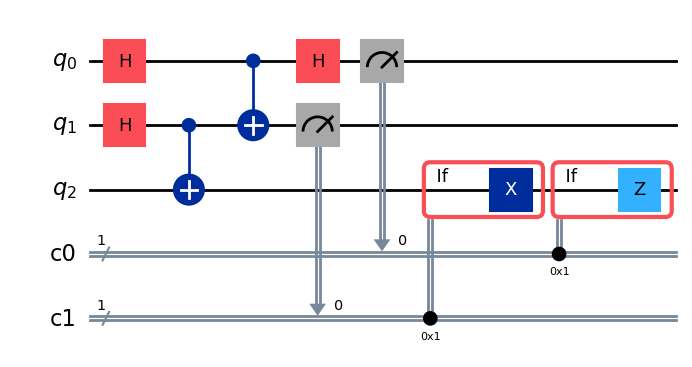

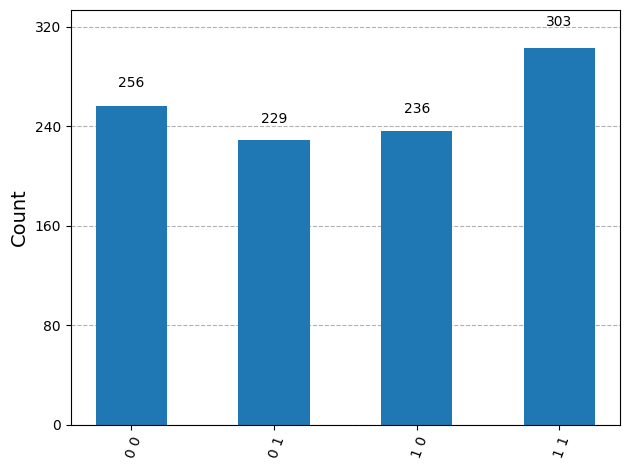

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

# ---------------------------------
# Registers
# ---------------------------------
q = QuantumRegister(3, "q")
c0 = ClassicalRegister(1, "c0")
c1 = ClassicalRegister(1, "c1")

qc = QuantumCircuit(q, c0, c1)

# ---------------------------------
# Step 1: Prepare the state to teleport
# ---------------------------------
qc.h(q[0])        # Message qubit (|+⟩ state)

# ---------------------------------
# Step 2: Create Bell Pair
# ---------------------------------
qc.h(q[1])
qc.cx(q[1], q[2])

# ---------------------------------
# Step 3: Bell Measurement
# ---------------------------------
qc.cx(q[0], q[1])
qc.h(q[0])

# ---------------------------------
# Step 4: Measure Alice's qubits
# ---------------------------------
qc.measure(q[0], c0)
qc.measure(q[1], c1)

# ---------------------------------
# Step 5: Bob's Corrections
# ---------------------------------
with qc.if_test((c1, 1)):
    qc.x(q[2])

with qc.if_test((c0, 1)):
    qc.z(q[2])

# Draw the circuit
display(qc.draw("mpl"))

# ---------------------------------
# Simulate
# ---------------------------------
sim = AerSimulator()
compiled = transpile(qc, sim)

result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

display(plot_histogram(counts))